In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score
import torch
import torch.nn as nn
import torch.optim as optim
import os

In [85]:
data_dir = '../data'
aapl_prices = pd.read_csv(os.path.join(data_dir, 'aapl_prices.csv'))
aapl_raw = pd.read_csv(os.path.join(data_dir, 'aapl_raw.csv'))
feat_imp = pd.read_csv(os.path.join(data_dir, 'feat_imp.csv'))
features = pd.read_csv(os.path.join(data_dir, 'features.csv'))
prices = pd.read_csv(os.path.join(data_dir, 'prices.csv'))
returns = pd.read_csv(os.path.join(data_dir, 'returns.csv'))
target = pd.read_csv(os.path.join(data_dir, 'target.csv'))
y_pred_lr = pd.read_csv(os.path.join(data_dir, 'y_pred_lr.csv'))
y_pred_rf = pd.read_csv(os.path.join(data_dir, 'y_pred_rf.csv'))
y_test = pd.read_csv(os.path.join(data_dir, 'y_test.csv'))

print("Loaded all data files!")

Loaded all data files!


In [86]:
# Recreate Train/Test Split from 03_models
features = pd.read_csv(os.path.join(data_dir, 'features.csv'), index_col=0, parse_dates=True)
target = pd.read_csv(os.path.join(data_dir, 'target.csv'), index_col=0, parse_dates=True).squeeze()

feature_names = features.columns.tolist()
X = features.replace([np.inf, -np.inf], np.nan)
y = target

data = X.join(y.rename('target')).dropna()
X = data[feature_names]
y = data['target']

n = int(len(data) * 0.8)
X_train, X_test = X.iloc[:n], X.iloc[n:]
y_train, y_test = y.iloc[:n], y.iloc[n:]

print(f"Train: {X_train.index.min()} → {X_train.index.max()}")
print(f"Test:  {X_test.index.min()} → {X_test.index.max()}")


Train: 2018-04-05 00:00:00 → 2022-11-02 00:00:00
Test:  2022-11-03 00:00:00 → 2023-12-28 00:00:00


In [87]:
from sklearn.preprocessing import StandardScaler

# Scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Create tensors from scaled data
X_train_t = torch.tensor(X_train_sc, dtype=torch.float32)
X_test_t = torch.tensor(X_test_sc, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# Val split from scaled tensors
val_size = int(0.15 * len(X_train_t))
X_val_t = X_train_t[-val_size:]
y_val_t = y_train_t[-val_size:]
X_tr_t = X_train_t[:-val_size]
y_tr_t = y_train_t[:-val_size]

# Verify
print("X_tr_t max:", X_tr_t.max().item())
print("X_tr_t min:", X_tr_t.min().item())
print("y_tr_t sample:", y_tr_t[:3])


X_tr_t max: 7.678902626037598
X_tr_t min: -6.599236488342285
y_tr_t sample: tensor([[-0.0259],
        [ 0.0099],
        [ 0.0186]])


In [88]:
class StockMLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.network(x)



In [89]:
model = StockMLP(n_features=27)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

Epoch 0 | Loss: 0.012937
Epoch 100 | Loss: 0.000416
Epoch 200 | Loss: 0.000274
Epoch 300 | Loss: 0.000210
Epoch 400 | Loss: 0.000167
Epoch 500 | Loss: 0.000137
Epoch 600 | Loss: 0.000114
Epoch 700 | Loss: 0.000094
Epoch 800 | Loss: 0.000079
Epoch 900 | Loss: 0.000065
Epoch 1000 | Loss: 0.000054
Epoch 1100 | Loss: 0.000049
Epoch 1200 | Loss: 0.000040
Epoch 1300 | Loss: 0.000035
Epoch 1400 | Loss: 0.000033
Epoch 1500 | Loss: 0.000030
Epoch 1600 | Loss: 0.000026
Epoch 1700 | Loss: 0.000022
Epoch 1800 | Loss: 0.000022
Epoch 1900 | Loss: 0.000016


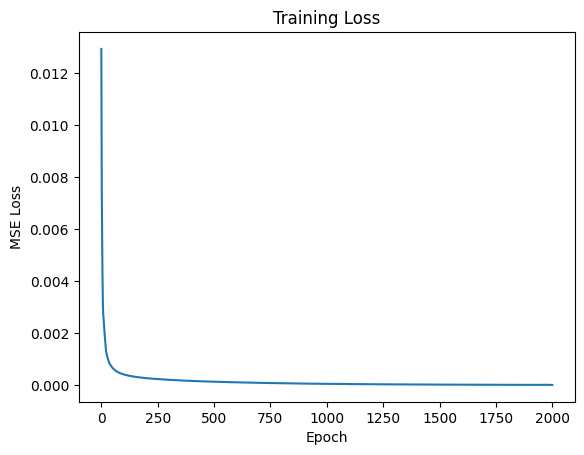

In [90]:
# You need to store losses during training first
# Re-run your training loop with this modification:

losses = []
model = StockMLP(n_features=27)  # reinitialize
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model.train()
for epoch in range(2000):
    optimizer.zero_grad()
    preds = model(X_train_t)
    loss = criterion(preds, y_train_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.6f}")

plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

In [91]:
model.eval()
with torch.no_grad():
    y_pred_mlp = model(X_test_t).squeeze().numpy()

from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import spearmanr

rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2_mlp = r2_score(y_test, y_pred_mlp)
dir_acc_mlp = (np.sign(y_pred_mlp) == np.sign(y_test)).mean()
ic_mlp, pval_mlp = spearmanr(y_pred_mlp, y_test)

print(f"MLP RMSE: {rmse_mlp:.5f}")
print(f"MLP R²: {r2_mlp:.4f}")
print(f"MLP Directional Accuracy: {dir_acc_mlp:.3f}")
print(f"MLP IC: {ic_mlp:.4f}  p={pval_mlp:.4f}")

MLP RMSE: 0.02736
MLP R²: -2.4775
MLP Directional Accuracy: 0.509
MLP IC: 0.0338  p=0.5674


In [92]:
class StockMLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.network(x)

model = StockMLP(n_features=27)
print(model)

StockMLP(
  (network): Sequential(
    (0): Linear(in_features=27, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [93]:
best_val_loss = float('inf')
patience_counter = 0
patience = 50

model.train()
for epoch in range(2000):
    optimizer.zero_grad()
    preds = model(X_tr_t)
    loss = criterion(preds, y_tr_t)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t)
        val_loss = criterion(val_preds, y_val_t)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        patience_counter += 1

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Train Loss: {loss.item():.6f} | Val Loss: {val_loss.item():.6f}")

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

    model.train()

Epoch 0 | Train Loss: 0.015838 | Val Loss: 0.007638
Early stopping at epoch 50


In [94]:
print(y_tr_t[:5])
print(y_tr_t.max(), y_tr_t.min())

tensor([[-0.0259],
        [ 0.0099],
        [ 0.0186],
        [-0.0047],
        [ 0.0098]])
tensor(0.1132) tensor(-0.1377)


In [95]:
print(X_train_sc[:2])
print(X_train_sc.max(), X_train_sc.min())

[[-1.25240326 -1.2194832  -1.20644462 -1.24095564 -1.22441283 -0.27870888
  -1.34798856 -0.40075628 -0.39961912 -0.33497958 -0.18397366 -0.77090059
  -1.1869421  -1.2194832  -1.22526913 -1.20799463 -0.37213931 -0.20310025
  -0.60237114  0.8406914   0.4271107  -0.36633513  0.31630214 -0.58204077
  -0.53107238 -0.56859047 -0.46255837]
 [-1.25178178 -1.2217024  -1.20697881 -1.2427951  -1.22573455 -0.75518291
  -1.34798856 -0.4113478  -0.40760256 -0.85872421 -0.11240981 -0.06245031
   0.033517   -1.2217024  -1.22707281 -1.21067722 -0.9464933  -0.1871607
   0.06020421  0.27242571  0.83977207  0.42683479 -0.36547807  0.31575778
  -0.0395569  -0.48485652 -0.41707696]]
7.67890244980224 -6.599236564537491


In [96]:
print(y_tr_t[:5])
print(y_tr_t.max(), y_tr_t.min())

tensor([[-0.0259],
        [ 0.0099],
        [ 0.0186],
        [-0.0047],
        [ 0.0098]])
tensor(0.1132) tensor(-0.1377)


In [97]:
model.eval()
with torch.no_grad():
    test_preds = model(X_tr_t[:5])
    print("Predictions:", test_preds)
    print("Targets:", y_tr_t[:5])

Predictions: tensor([[ 0.0492],
        [ 0.0361],
        [ 0.0611],
        [-0.0246],
        [-0.0004]])
Targets: tensor([[-0.0259],
        [ 0.0099],
        [ 0.0186],
        [-0.0047],
        [ 0.0098]])


In [98]:
model2 = StockMLP(n_features=27)
with torch.no_grad():
    test_out = model2(X_tr_t[:3])
    print("Fresh model output:", test_out)
    print("Target:", y_tr_t[:3])
    loss_test = criterion(test_out, y_tr_t[:3])
    print("Loss:", loss_test)

Fresh model output: tensor([[-0.0209],
        [-0.1036],
        [-0.1247]])
Target: tensor([[-0.0259],
        [ 0.0099],
        [ 0.0186]])
Loss: tensor(0.0111)


In [99]:
print("X_tr_t sample:", X_tr_t[0])
print("X_tr_t max:", X_tr_t.max().item())
print("X_tr_t min:", X_tr_t.min().item())

X_tr_t sample: tensor([-1.2524, -1.2195, -1.2064, -1.2410, -1.2244, -0.2787, -1.3480, -0.4008,
        -0.3996, -0.3350, -0.1840, -0.7709, -1.1869, -1.2195, -1.2253, -1.2080,
        -0.3721, -0.2031, -0.6024,  0.8407,  0.4271, -0.3663,  0.3163, -0.5820,
        -0.5311, -0.5686, -0.4626])
X_tr_t max: 7.678902626037598
X_tr_t min: -6.599236488342285
